# Laboratorio 06 - Lab05: Clasificación Multiclase con PyTorch

## Clasificación de Dígitos MNIST-M

**Estudiante:** Emily Karen Villarpando Olmedo

# 1. Librerías

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 2. Cargar el dataset

In [13]:
ruta = '/content/drive/MyDrive/Inteligencia Artificial/Laboratorio 06/'

train = pd.read_parquet(
    ruta + 'train-00000-of-00001-571b6b1e2c195186.parquet'
)

test = pd.read_parquet(
    ruta + 'test-00000-of-00001-ba3ad971b105ff65.parquet'
)

df = pd.concat([train, test], ignore_index=True)

print("Cantidad total de ejemplos:", len(df))
print("Columnas:", df.columns.tolist())

df.head()

Cantidad total de ejemplos: 68002
Columnas: ['image', 'label']


,image,label
0,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,0
1,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,0
2,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,0
3,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,0
4,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,0


# 3. Exploración de las clases

In [14]:
# Distribución de las clases

distribucion = df['label'].value_counts().sort_index()

print("Distribución de clases:")
print(distribucion)

print("\nNúmero de clases:", df['label'].nunique())
print("Clase con menor cantidad:", distribucion.min())

Distribución de clases:
label
0    6703
1    7656
2    6786
3    6936
4    6636
5    6138
6    6668
7    7072
8    6637
9    6770
Name: count, dtype: int64

Número de clases: 10
Clase con menor cantidad: 6138


# 4. Balanceo de clases

In [15]:
# Cantidad mínima por clase
minimo = df['label'].value_counts().min()

# Tomar la misma cantidad de ejemplos de cada clase
df_balanceado = pd.concat([
    grupo.sample(n=minimo, random_state=42)
    for _, grupo in df.groupby('label')
]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Cantidad total después del balanceo:", len(df_balanceado))

print("\nDistribución después del balanceo:")
print(df_balanceado['label'].value_counts().sort_index())

Cantidad total después del balanceo: 61380

Distribución después del balanceo:
label
0    6138
1    6138
2    6138
3    6138
4    6138
5    6138
6    6138
7    6138
8    6138
9    6138
Name: count, dtype: int64


# 5. Preprocesamiento de las imágenes

Tamaño original: (32, 32)
Modo de color: RGB


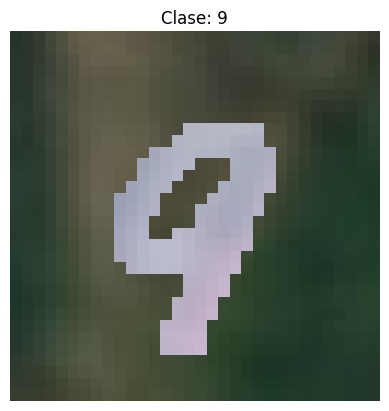

In [16]:
import io
from PIL import Image

# Tomar una imagen del dataset
datos_imagen = df_balanceado.iloc[0]['image']

# Convertir los bytes PNG a imagen
imagen = Image.open(io.BytesIO(datos_imagen['bytes']))

print("Tamaño original:", imagen.size)
print("Modo de color:", imagen.mode)

plt.imshow(imagen)
plt.title(f"Clase: {df_balanceado.iloc[0]['label']}")
plt.axis('off')
plt.show()

# 6. Convertir imágenes a 28x28, escala de grises y vector de 784

In [17]:
X = []
y = []

for i, fila in df_balanceado.iterrows():

    # Recuperar imagen desde bytes
    imagen = Image.open(
        io.BytesIO(fila['image']['bytes'])
    )

    # Convertir a escala de grises
    imagen = imagen.convert('L')

    # Redimensionar de 32x32 a 28x28
    imagen = imagen.resize((28, 28))

    # Convertir a arreglo NumPy
    arreglo = np.array(imagen)

    # Convertir 28x28 en vector de 784
    arreglo = arreglo.flatten()

    X.append(arreglo)
    y.append(fila['label'])


X = np.array(X)
y = np.array(y)

print("X:", X.shape)
print("y:", y.shape)
print("Rango de píxeles:", X.min(), "-", X.max())

X: (61380, 784)
y: (61380,)
Rango de píxeles: 0 - 255


# 7. Normalización

In [18]:
X = X.astype(np.float32) / 255.0

print("Normalización completada")
print("Valor mínimo:", X.min())
print("Valor máximo:", X.max())

Normalización completada
Valor mínimo: 0.0
Valor máximo: 1.0


# 8. División del dataset 80/20

In [19]:
np.random.seed(42)

indices = np.random.permutation(len(X))

corte = int(len(X) * 0.8)

indices_train = indices[:corte]
indices_test = indices[corte:]

X_train = X[indices_train]
y_train = y[indices_train]

X_test = X[indices_test]
y_test = y[indices_test]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (49104, 784)
y_train: (49104,)
X_test: (12276, 784)
y_test: (12276,)


# 9. TensorDataset y DataLoader

In [20]:
# Convertir NumPy a tensores

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)


# Crear Dataset

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)


# Crear DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)


print("Datos de entrenamiento:", len(train_dataset))
print("Datos de prueba:", len(test_dataset))

print("Lotes de entrenamiento:", len(train_loader))
print("Lotes de prueba:", len(test_loader))


# Revisar un lote
X_batch, y_batch = next(iter(train_loader))

print("\nForma de X_batch:", X_batch.shape)
print("Forma de y_batch:", y_batch.shape)

Datos de entrenamiento: 49104
Datos de prueba: 12276
Lotes de entrenamiento: 384
Lotes de prueba: 96

Forma de X_batch: torch.Size([128, 784])
Forma de y_batch: torch.Size([128])


# 10. Red Neuronal con PyTorch



In [21]:
# Dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Dispositivo utilizado:", device)

# Arquitectura
D_in = 784
H = 100
D_out = 10

model = nn.Sequential(
    nn.Linear(D_in, H),
    nn.ReLU(),
    nn.Linear(H, D_out)
).to(device)

print(model)

Dispositivo utilizado: cpu
Sequential(
  (0): Linear(in_features=784, out_features=100, bias=True)
  (1): ReLU()
  (2): Linear(in_features=100, out_features=10, bias=True)
)


# 11. Función de pérdida y optimizador

In [22]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.001
)

print("Función de pérdida:", criterion)
print("Optimizador:", optimizer.__class__.__name__)

Función de pérdida: CrossEntropyLoss()
Optimizador: SGD


# 12. Entrenamiento de la red

In [24]:
epochs = 40
losses = []

for e in range(1, epochs + 1):

    model.train()
    loss_epoch = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        y_pred = model(X_batch)

        loss = criterion(y_pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_epoch += loss.item()

    loss_epoch /= len(train_loader)
    losses.append(loss_epoch)

    print(f"Epoch {e}/{epochs} - Loss: {loss_epoch:.5f}")

Epoch 1/40 - Loss: 2.14070
Epoch 2/40 - Loss: 2.13298
Epoch 3/40 - Loss: 2.12446
Epoch 4/40 - Loss: 2.11616
Epoch 5/40 - Loss: 2.10796
Epoch 6/40 - Loss: 2.09955
Epoch 7/40 - Loss: 2.09108
Epoch 8/40 - Loss: 2.08250
Epoch 9/40 - Loss: 2.07380
Epoch 10/40 - Loss: 2.06512
Epoch 11/40 - Loss: 2.05631
Epoch 12/40 - Loss: 2.04726
Epoch 13/40 - Loss: 2.03822
Epoch 14/40 - Loss: 2.02918
Epoch 15/40 - Loss: 2.01996
Epoch 16/40 - Loss: 2.01080
Epoch 17/40 - Loss: 2.00113
Epoch 18/40 - Loss: 1.99049
Epoch 19/40 - Loss: 1.98050
Epoch 20/40 - Loss: 1.96975
Epoch 21/40 - Loss: 1.95962
Epoch 22/40 - Loss: 1.95005
Epoch 23/40 - Loss: 1.94055
Epoch 24/40 - Loss: 1.93115
Epoch 25/40 - Loss: 1.92174
Epoch 26/40 - Loss: 1.91247
Epoch 27/40 - Loss: 1.90323
Epoch 28/40 - Loss: 1.89411
Epoch 29/40 - Loss: 1.88522
Epoch 30/40 - Loss: 1.87614
Epoch 31/40 - Loss: 1.86743
Epoch 32/40 - Loss: 1.85870
Epoch 33/40 - Loss: 1.85006
Epoch 34/40 - Loss: 1.84155
Epoch 35/40 - Loss: 1.83309
Epoch 36/40 - Loss: 1.82492
E

# 13. Gráfica de pérdida

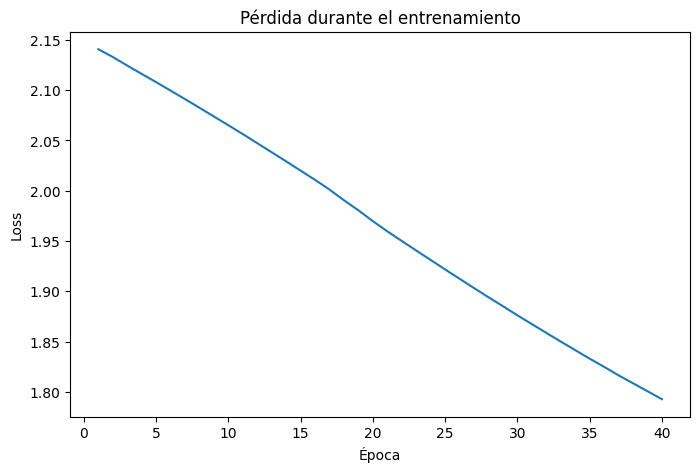

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, epochs + 1), losses)

plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Pérdida durante el entrenamiento")

plt.show()

# 14. Evaluación de métricas

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def obtener_predicciones(loader):
    reales = []
    predicciones = []

    model.eval()

    with torch.no_grad():
        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)

            salida = model(X_batch)
            pred = torch.argmax(salida, dim=1)

            reales.extend(y_batch.numpy())
            predicciones.extend(pred.cpu().numpy())

    return reales, predicciones


# Predicciones
y_train_real, y_train_pred = obtener_predicciones(train_loader)
y_test_real, y_test_pred = obtener_predicciones(test_loader)

# Métricas
accuracy_train = accuracy_score(y_train_real, y_train_pred)
accuracy_test = accuracy_score(y_test_real, y_test_pred)

precision = precision_score(
    y_test_real,
    y_test_pred,
    average='macro'
)

recall = recall_score(
    y_test_real,
    y_test_pred,
    average='macro'
)

f1 = f1_score(
    y_test_real,
    y_test_pred,
    average='macro'
)

print("Métricas del modelo")
print("-------------------------")
print(f"Accuracy entrenamiento: {accuracy_train * 100:.2f}%")
print(f"Accuracy prueba        : {accuracy_test * 100:.2f}%")
print(f"Precision              : {precision:.4f}")
print(f"Recall                 : {recall:.4f}")
print(f"F1-Score               : {f1:.4f}")

Métricas del modelo
-------------------------
Accuracy entrenamiento: 46.76%
Accuracy prueba        : 47.47%
Precision              : 0.5115
Recall                 : 0.4743
F1-Score               : 0.4778


# 15. Ejemplos de predicciones

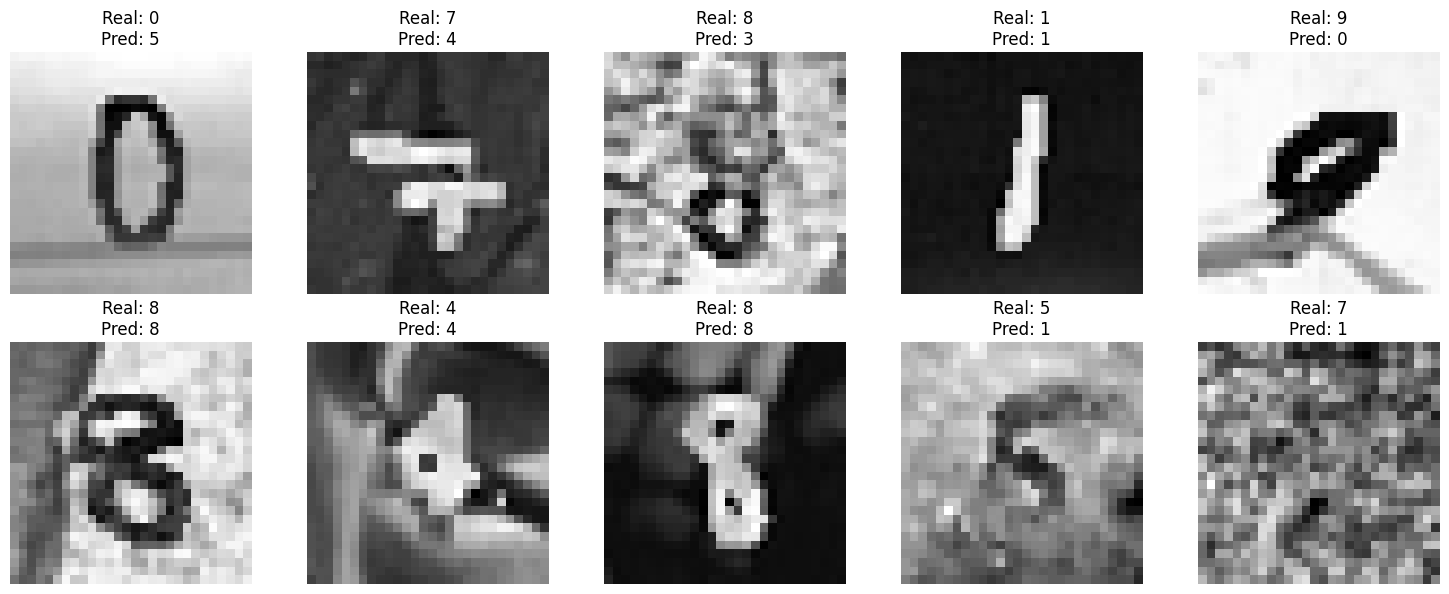

In [27]:
# Seleccionar 10 imágenes aleatorias del conjunto de prueba
indices = np.random.choice(len(X_test), 10, replace=False)

plt.figure(figsize=(15, 6))

for i, indice in enumerate(indices):

    imagen = X_test[indice].reshape(28, 28)

    real = y_test_real[indice]
    prediccion = y_test_pred[indice]

    plt.subplot(2, 5, i + 1)

    plt.imshow(imagen, cmap='gray')
    plt.title(f"Real: {real}\nPred: {prediccion}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# 16. Guardar los pesos

In [28]:
from google.colab import drive
drive.mount('/content/drive')

ruta_modelo = '/content/drive/MyDrive/Inteligencia Artificial/Laboratorio 06/modelo_lab05_karen_pytorch.pth'

torch.save(model.state_dict(), ruta_modelo)

print("Modelo guardado correctamente")
print("Ruta:", ruta_modelo)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Modelo guardado correctamente
Ruta: /content/drive/MyDrive/Inteligencia Artificial/Laboratorio 06/modelo_lab05_karen_pytorch.pth
